In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Crop_recommendation.csv to Crop_recommendation.csv


## Import libraries

In [ ]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

Read Dataset

In [ ]:
df=pd.read_csv('Crop_recommendation.csv')
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [ ]:
import plotly.express as px
fig = px.pie(df, names='label', title="Crop Distribution")

fig.update_layout(
    width=800,
    height=600
)
fig.show()

In [ ]:
for col in df.columns:
  plt.figure(figsize=(10,4))
  sns.histplot(df[col], kde=(col!='label'), color='red')
  plt.title(col)
  if col!='label':
    plt.xticks(rotation=90)
  plt.tight_layout()
  plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

df1 = df.copy()

le=LabelEncoder()
df1["label"]=le.fit_transform(df1["label"])

plt.figure(figsize=(8,6))
sns.heatmap(df1.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
px.treemap(
    df,
    path=['label'],
    values='rainfall',
    title="Crop Treemap"
).show()

In [ ]:
sns.pairplot(df)
plt.show()

## Import libraries

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

##Feature Selection

In [ ]:
X = df.drop('label', axis=1)
y = df['label']

##Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, random_state=42)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred =knn.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9568181818181818


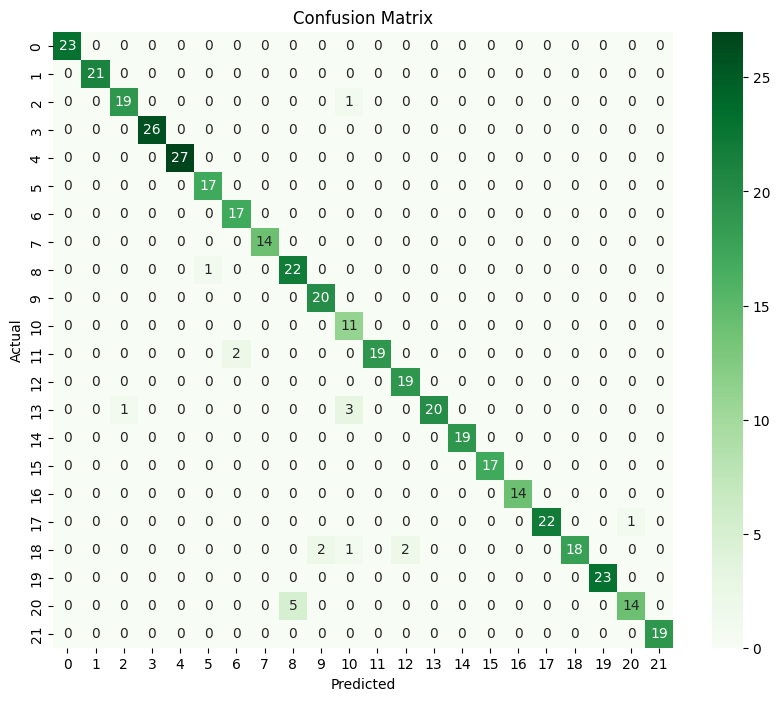

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
import joblib

joblib.dump(knn, "Agro_model.pkl")

['Agro_model.pkl']